<a href="https://colab.research.google.com/github/farahkhaterr/emotions-ai-detector/blob/main/Another_copy_of_emotion_detection_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/pankaj4321/fer-2013-facial-expression-dataset?utm_source=chatgpt.com")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: farah
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/pankaj4321/fer-2013-facial-expression-dataset


100%|██████████| 65.1M/65.1M [00:01<00:00, 45.1MB/s]


In [ ]:
import os

print("Files and folders in /content:")
print(os.listdir("/content"))

Files and folders in /content:
['.config', 'fer-2013-facial-expression-dataset', 'sample_data']


In [ ]:
import os

for item in os.listdir("/content"):
    path = os.path.join("/content", item)

    if os.path.isdir(path):
        print("\n📁", item)
        print(os.listdir(path)[:20])


📁 .config
['config_sentinel', '.last_update_check.json', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'gce', 'default_configs.db', 'configurations', 'logs', 'active_config', '.last_opt_in_prompt.yaml', '.last_survey_prompt.yaml']

📁 fer-2013-facial-expression-dataset
['test', 'val', 'train']

📁 sample_data
['anscombe.json', 'README.md', 'california_housing_train.csv', 'mnist_train_small.csv', 'mnist_test.csv', 'california_housing_test.csv']


In [ ]:
import os
from collections import Counter

dataset_path = "/content/fer-2013-facial-expression-dataset"

for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n📂 {split.upper()}")

    classes = sorted(os.listdir(split_path))
    print("Classes:", classes)

    total = 0

    for emotion in classes:
        emotion_path = os.path.join(split_path, emotion)

        if os.path.isdir(emotion_path):
            count = len([
                f for f in os.listdir(emotion_path)
                if os.path.isfile(os.path.join(emotion_path, f))
            ])

            print(f"{emotion}: {count}")
            total += count

    print("Total:", total)


📂 TRAIN
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Angry: 3995
Disgust: 436
Fear: 4097
Happy: 7215
Neutral: 4965
Sad: 4830
Surprise: 3171
Total: 28709

📂 VAL
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Angry: 467
Disgust: 56
Fear: 496
Happy: 895
Neutral: 607
Sad: 653
Surprise: 415
Total: 3589

📂 TEST
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Angry: 491
Disgust: 55
Fear: 528
Happy: 879
Neutral: 626
Sad: 594
Surprise: 416
Total: 3589


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

dataset_path = "/content/fer-2013-facial-expression-dataset"

splits = ["train", "val", "test"]

data = []

for split in splits:
    split_path = os.path.join(dataset_path, split)

    for emotion in sorted(os.listdir(split_path)):
        emotion_path = os.path.join(split_path, emotion)

        if os.path.isdir(emotion_path):
            count = len([
                f for f in os.listdir(emotion_path)
                if os.path.isfile(os.path.join(emotion_path, f))
            ])

            data.append([split, emotion, count])

df_counts = pd.DataFrame(
    data,
    columns=["Split", "Emotion", "Count"]
)

df_counts

,Split,Emotion,Count
0,train,Angry,3995
1,train,Disgust,436
2,train,Fear,4097
3,train,Happy,7215
4,train,Neutral,4965
5,train,Sad,4830
6,train,Surprise,3171
7,val,Angry,467
8,val,Disgust,56
9,val,Fear,496


In [ ]:
total_images = df_counts["Count"].sum()

print("Total number of images:", total_images)

for split in splits:
    total = df_counts[df_counts["Split"] == split]["Count"].sum()
    print(f"{split}: {total}")

Total number of images: 35887
train: 28709
val: 3589
test: 3589


In [ ]:
classes = sorted(df_counts["Emotion"].unique())

print("Number of classes:", len(classes))
print("Classes:")

for i, emotion in enumerate(classes):
    print(i, "→", emotion)

Number of classes: 7
Classes:
0 → Angry
1 → Disgust
2 → Fear
3 → Happy
4 → Neutral
5 → Sad
6 → Surprise


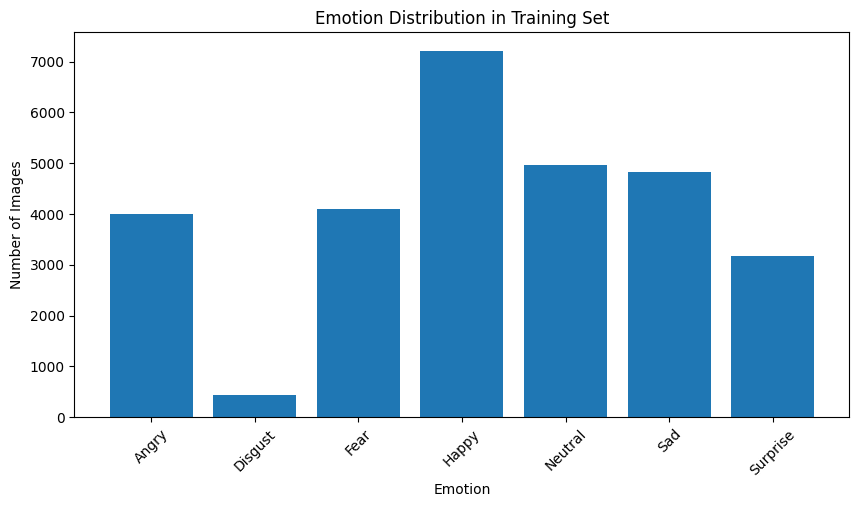

In [ ]:
train_counts = df_counts[df_counts["Split"] == "train"]

plt.figure(figsize=(10, 5))

plt.bar(
    train_counts["Emotion"],
    train_counts["Count"]
)

plt.title("Emotion Distribution in Training Set")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.show()

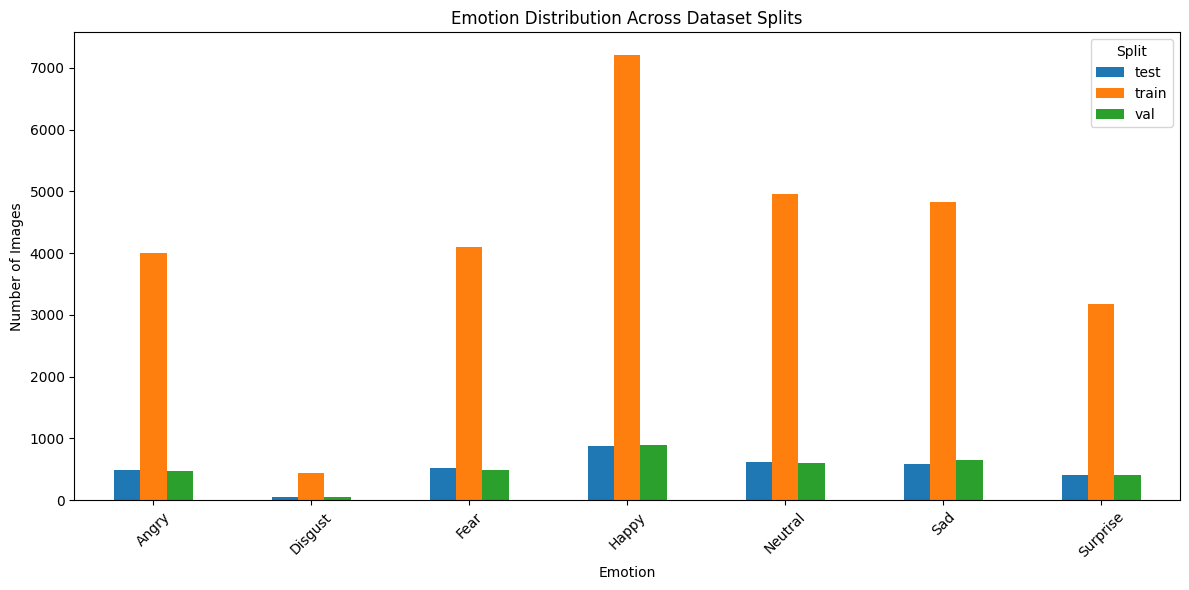

In [ ]:
distribution = df_counts.pivot(
    index="Emotion",
    columns="Split",
    values="Count"
)

distribution.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Emotion Distribution Across Dataset Splits")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
train_counts = train_counts.copy()

train_total = train_counts["Count"].sum()

train_counts["Percentage"] = (
    train_counts["Count"] / train_total * 100
)

train_counts

,Split,Emotion,Count,Percentage
0,train,Angry,3995,13.915497
1,train,Disgust,436,1.518688
2,train,Fear,4097,14.270786
3,train,Happy,7215,25.131492
4,train,Neutral,4965,17.294228
5,train,Sad,4830,16.823992
6,train,Surprise,3171,11.045317


In [ ]:
max_class = train_counts.loc[
    train_counts["Count"].idxmax()
]

min_class = train_counts.loc[
    train_counts["Count"].idxmin()
]

print("Largest class:")
print(max_class)

print("\nSmallest class:")
print(min_class)

Largest class:
Split             train
Emotion           Happy
Count              7215
Percentage    25.131492
Name: 3, dtype: object

Smallest class:
Split            train
Emotion        Disgust
Count              436
Percentage    1.518688
Name: 1, dtype: object


In [ ]:
imbalance_ratio = (
    max_class["Count"] / min_class["Count"]
)

print(
    f"Imbalance Ratio: {imbalance_ratio:.2f}"
)

Imbalance Ratio: 16.55


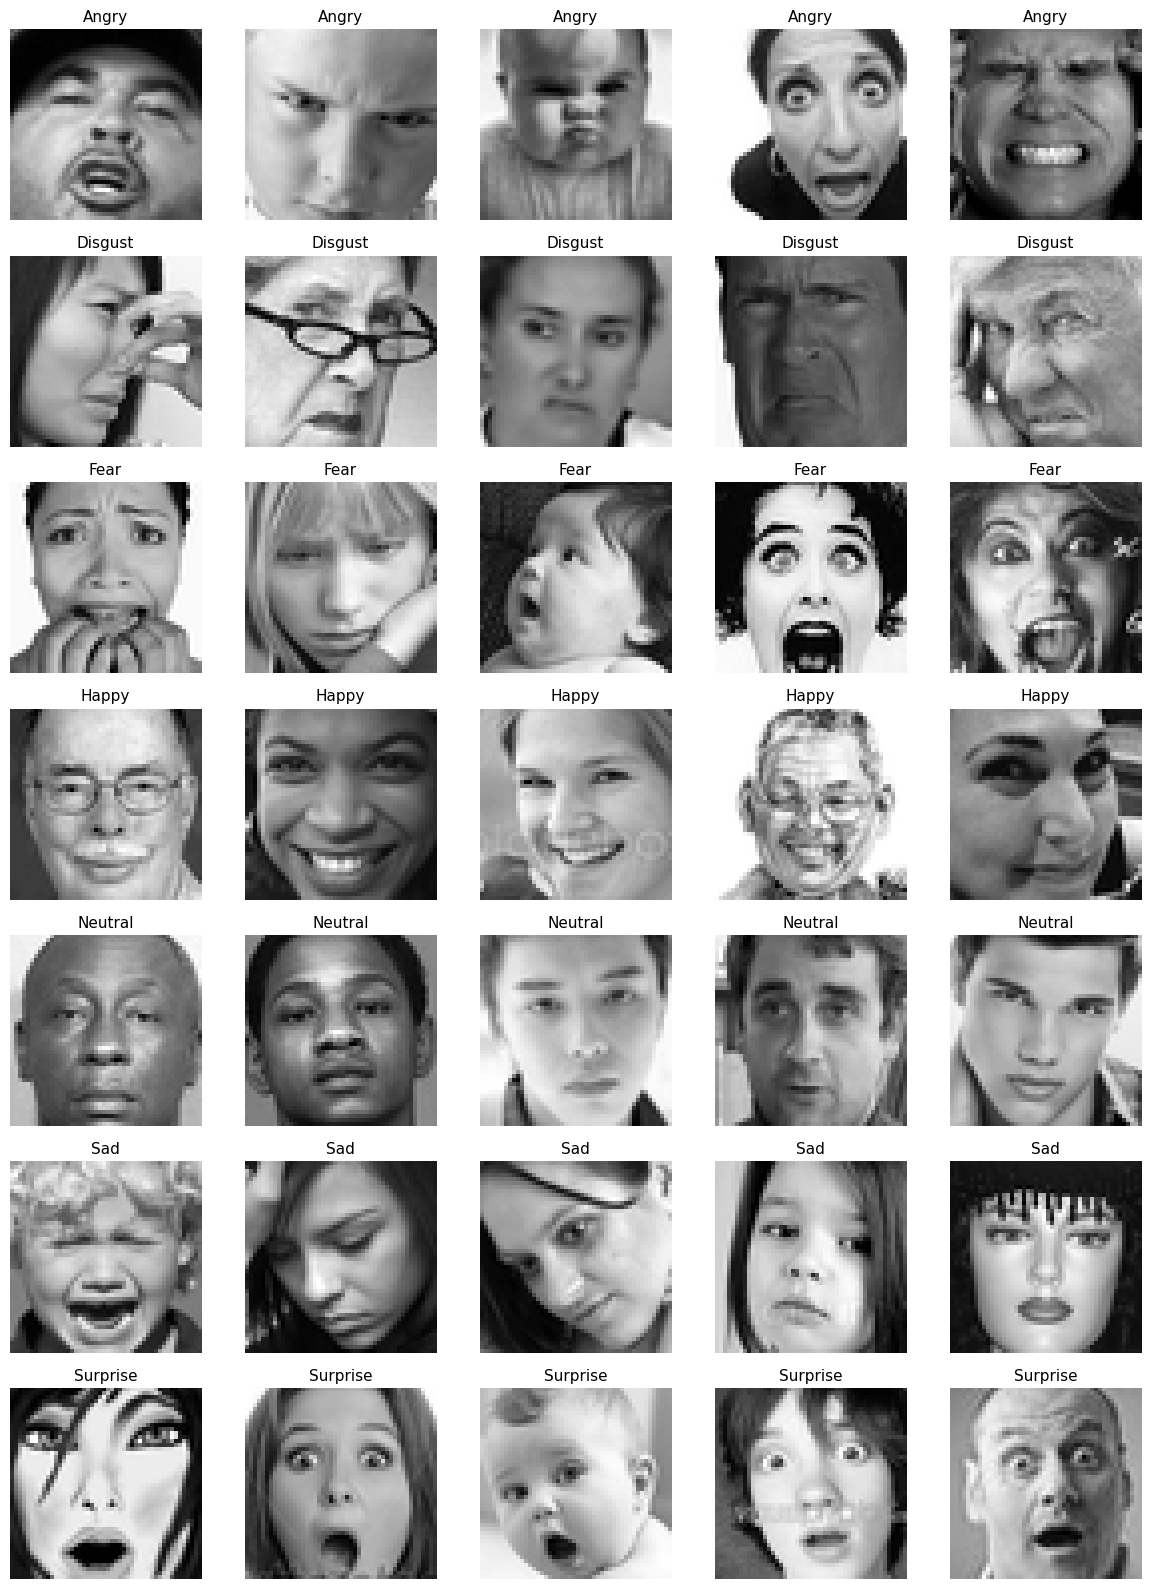

In [ ]:
from PIL import Image
import random
import matplotlib.pyplot as plt
import os

classes = sorted(df_counts["Emotion"].unique())

fig, axes = plt.subplots(
    len(classes),
    5,
    figsize=(12, 16)
)

for i, emotion in enumerate(classes):

    folder = os.path.join(
        dataset_path,
        "train",
        emotion
    )

    images = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ]

    samples = random.sample(
        images,
        min(5, len(images))
    )

    for j, image_name in enumerate(samples):

        image_path = os.path.join(
            folder,
            image_name
        )

        image = Image.open(image_path)

        axes[i, j].imshow(image, cmap="gray")
        axes[i, j].set_title(emotion, fontsize=11)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
from collections import Counter

sizes = Counter()

train_path = os.path.join(dataset_path, "train")

for emotion in classes:

    emotion_path = os.path.join(
        train_path,
        emotion
    )

    for image_file in os.listdir(emotion_path):

        image_path = os.path.join(
            emotion_path,
            image_file
        )

        try:
            image = Image.open(image_path)
            sizes[image.size] += 1
        except:
            pass

print("Image dimensions:")
for size, count in sizes.items():
    print(size, "→", count)

Image dimensions:
(48, 48) → 28709


In [ ]:
modes = Counter()

for emotion in classes:

    emotion_path = os.path.join(
        train_path,
        emotion
    )

    for image_file in os.listdir(emotion_path):

        image_path = os.path.join(
            emotion_path,
            image_file
        )

        try:
            image = Image.open(image_path)
            modes[image.mode] += 1
        except:
            pass

print("Image modes:")
print(modes)

Image modes:
Counter({'L': 28709})


In [ ]:
import numpy as np

brightness_values = []

for emotion in classes:

    folder = os.path.join(
        dataset_path,
        "train",
        emotion
    )

    for image_name in random.sample(
        os.listdir(folder),
        min(100, len(os.listdir(folder)))
    ):

        path = os.path.join(folder, image_name)

        image = Image.open(path).convert("L")

        brightness_values.append(
            np.array(image).mean()
        )

print(
    "Average Brightness:",
    np.mean(brightness_values)
)

Average Brightness: 131.85953621031746


In [ ]:
corrupted_images = []

for emotion in classes:
    folder = os.path.join(dataset_path, "train", emotion)

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except:
            corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


## 🧹 تنضيف الـ Train Set من الـ Noise (Corrupted + Brightness Outliers)
هنشيل من **الـ train set بس** (مش val ولا test، عشان نفضل نقيّم على بيانات واقعية):

1. **الصور الـ corrupted** (اللي جبناها فوق في `corrupted_images`).
2. **صور الـ brightness outliers** — صور برة ±2.5 standard deviations من متوسط السطوع (شديدة السواد أو شديدة البياض، غالباً صور فيها مشكلة).

⚠️ **إجراء أمان:** لو نسبة الحذف من أي كلاس أكتر من **5%**، هنوقف ونطبع تحذير بدل ما نشيل بشكل أعمى، عشان منضخمش مشكلة الـ imbalance اللي شفناها فوق.

الصور مش هتتمسح نهائياً من على الجهاز، هتتنقل لمجلد `/content/removed_noisy/` عشان تقدر ترجعها لو احتجت.

In [ ]:
import shutil

removed_root = "/content/removed_noisy"
os.makedirs(removed_root, exist_ok=True)

MAX_REMOVE_RATIO = 0.05   # سقف أمان: متشيلش أكتر من 5% من أي كلاس
BRIGHTNESS_ZSCORE_THRESHOLD = 2.5


In [ ]:
# 1) نحسب الـ brightness z-score outliers على كل صور الـ train (مش عينة بس زي في الـ EDA)
train_path = os.path.join(dataset_path, "train")

brightness_per_image = {}   # path -> brightness

for emotion in classes:
    emotion_path = os.path.join(train_path, emotion)

    for image_name in os.listdir(emotion_path):
        image_path = os.path.join(emotion_path, image_name)

        try:
            img = Image.open(image_path).convert("L")
            brightness_per_image[image_path] = np.array(img).mean()
        except:
            pass  # هتتمسك أصلاً في corrupted_images

print("Computed brightness for", len(brightness_per_image), "images")


Computed brightness for 28709 images


In [ ]:
# 2) نحدد الصور المرشحة للحذف: corrupted + brightness outliers، مقسّمة حسب الكلاس
corrupted_set = set(corrupted_images)

candidates_per_class = {emotion: [] for emotion in classes}

for emotion in classes:
    emotion_path = os.path.join(train_path, emotion)

    class_brightness = {
        p: b for p, b in brightness_per_image.items()
        if os.path.dirname(p) == emotion_path
    }

    values = np.array(list(class_brightness.values()))
    mean_b, std_b = values.mean(), values.std()

    for path, b in class_brightness.items():
        z = abs(b - mean_b) / (std_b + 1e-8)

        is_corrupted = path in corrupted_set
        is_outlier = z > BRIGHTNESS_ZSCORE_THRESHOLD

        if is_corrupted or is_outlier:
            candidates_per_class[emotion].append(path)

for emotion, paths in candidates_per_class.items():
    print(f"{emotion}: {len(paths)} candidate(s) for removal")


Angry: 43 candidate(s) for removal
Disgust: 6 candidate(s) for removal
Fear: 51 candidate(s) for removal
Happy: 74 candidate(s) for removal
Neutral: 35 candidate(s) for removal
Sad: 41 candidate(s) for removal
Surprise: 48 candidate(s) for removal


In [ ]:
# 3) نطبّق سقف الأمان (5%) ونعمل move فعلي للصور
removal_report = []

for emotion, paths in candidates_per_class.items():
    emotion_path = os.path.join(train_path, emotion)
    total_in_class = len(os.listdir(emotion_path))

    max_allowed = int(total_in_class * MAX_REMOVE_RATIO)

    to_remove = paths[:max_allowed] if len(paths) > max_allowed else paths

    if len(paths) > max_allowed:
        print(f"⚠️  {emotion}: {len(paths)} مرشحين لكن السقف {max_allowed} (5%) - هنشيل {max_allowed} بس")

    dest_dir = os.path.join(removed_root, emotion)
    os.makedirs(dest_dir, exist_ok=True)

    for path in to_remove:
        shutil.move(path, os.path.join(dest_dir, os.path.basename(path)))

    removal_report.append({
        "Emotion": emotion,
        "Original Count": total_in_class,
        "Removed": len(to_remove),
        "Remaining": total_in_class - len(to_remove),
        "Removed %": round(100 * len(to_remove) / total_in_class, 2)
    })

removal_report_df = pd.DataFrame(removal_report)
removal_report_df


,Emotion,Original Count,Removed,Remaining,Removed %
0,Angry,3995,43,3952,1.08
1,Disgust,436,6,430,1.38
2,Fear,4097,51,4046,1.24
3,Happy,7215,74,7141,1.03
4,Neutral,4965,35,4930,0.70
5,Sad,4830,41,4789,0.85
6,Surprise,3171,48,3123,1.51


**ملحوظة:** بعد تشغيل الخلايا دي، شغّل خلية `image_dataset_from_directory` (اللي بعدها) عادي - هي هتقرأ الـ train folder وتلاقيه أصلاً اتنضف، مش محتاج تعديل فيها.

لو عايز ترجع الصور المحذوفة في أي وقت، هي موجودة كاملة في `/content/removed_noisy/<emotion>/`.

In [ ]:
import tensorflow as tf

IMG_SIZE = (48, 48)
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"/content/fer-2013-facial-expression-dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"/content/fer-2013-facial-expression-dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"/content/fer-2013-facial-expression-dataset/test",
    image_size=IMG_SIZE,
    color_mode="grayscale",
    shuffle=False
)

Found 28411 files belonging to 7 classes.
Found 3589 files belonging to 7 classes.
Found 3589 files belonging to 7 classes.


In [ ]:
# Preprocessing
def preprocess(image, label):

    # Normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

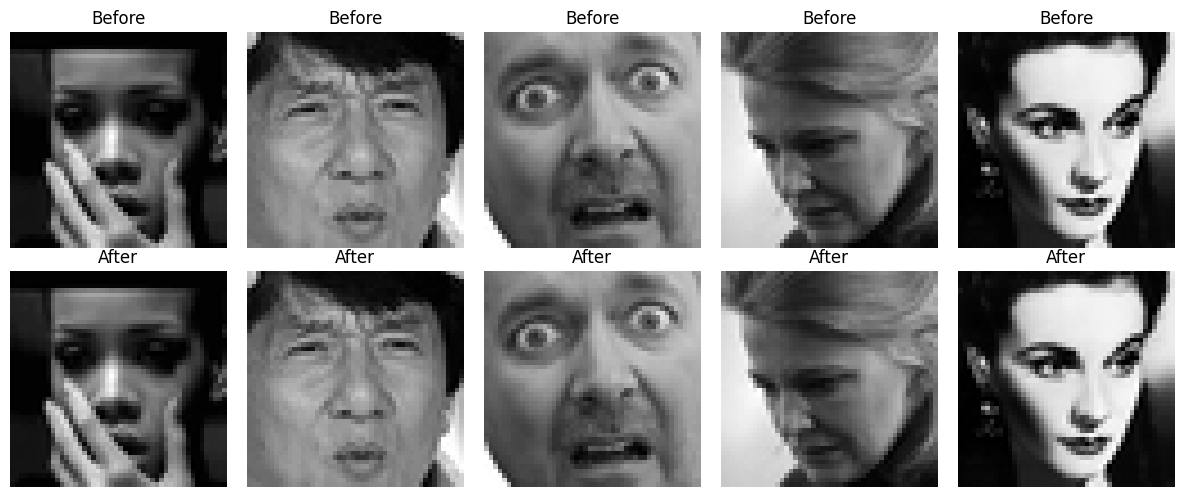

In [ ]:
for images, labels in train_ds.take(1):

    original_images = images[:5]

    processed_images, _ = preprocess(
        original_images,
        labels[:5]
    )

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for i in range(5):

        axes[0, i].imshow(
            original_images[i].numpy().squeeze(),
            cmap="gray"
        )
        axes[0, i].set_title("Before")
        axes[0, i].axis("off")

        axes[1, i].imshow(
            processed_images[i].numpy().squeeze(),
            cmap="gray"
        )
        axes[1, i].set_title("After")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),
    tf.keras.layers.RandomBrightness(0.15, value_range=(0, 1)),
    tf.keras.layers.RandomContrast(0.15)
])

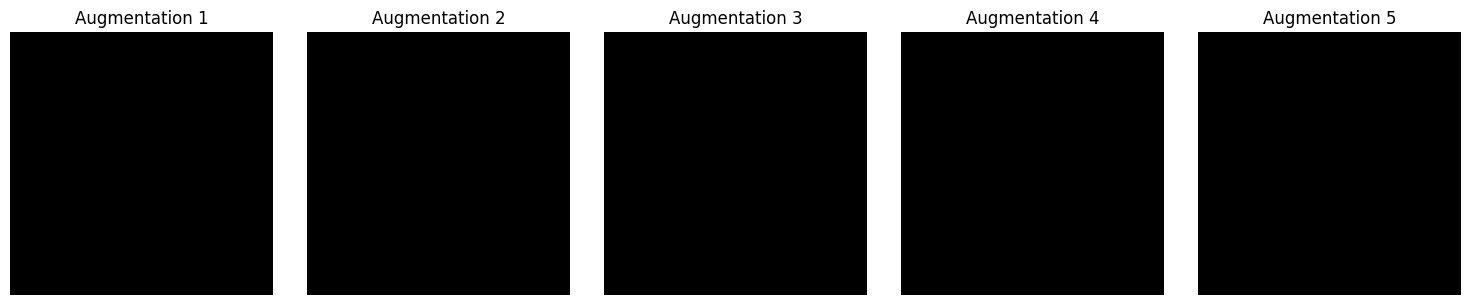

In [ ]:
for images, labels in train_ds.take(6):

    image = images[0]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for i in range(5):

        augmented = data_augmentation(
            tf.expand_dims(image, 0),
            training=True
        )[0]

        axes[i].imshow(
            augmented.numpy().squeeze(),
            cmap="gray"
        )

        axes[i].axis("off")
        axes[i].set_title(f"Augmentation {i+1}")

    plt.tight_layout()
    plt.show()

    break

In [ ]:
def train_preprocess(image, label):
    # Basic preprocessing
    image, label = preprocess(image, label)

    # Data augmentation - Train only
    image = data_augmentation(image, training=True)

    return image, label




In [ ]:
train_ds_final = train_ds.map(
    train_preprocess,
    num_parallel_calls=AUTOTUNE
)

train_ds_final = train_ds_final.prefetch(AUTOTUNE)

In [ ]:
val_ds_final = val_ds.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

val_ds_final = val_ds_final.prefetch(AUTOTUNE)

In [ ]:
test_ds_final = test_ds.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

test_ds_final = test_ds_final.prefetch(AUTOTUNE)

In [ ]:
for images, labels in train_ds_final.take(1):

    print("Train images shape:", images.shape)
    print("Train labels shape:", labels.shape)

    print(
        "Pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

Train images shape: (128, 48, 48, 1)
Train labels shape: (128,)
Pixel range: 0.0 to 1.0663784


In [ ]:
for images, labels in test_ds_final.take(1):

    print("\nTest images shape:", images.shape)
    print("Test labels shape:", labels.shape)

    print(
        "Pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )


Test images shape: (32, 48, 48, 1)
Test labels shape: (32,)
Pixel range: 0.0 to 1.0


##  Modeling Phase

In [ ]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt
import time

IMG_SHAPE = (48, 48, 1)
NUM_CLASSES = len(classes)

print("Input shape:", IMG_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", classes)


Input shape: (48, 48, 1)
Number of classes: 7
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [ ]:
def build_baseline_cnn(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    """
    Baseline CNN - simple stack, no regularization.
    Used as a reference point to visualize overfitting.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="baseline_cnn")

    return model


build_baseline_cnn().summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,375 (4.86 MB)

 Trainable params: 1,274,375 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_cnn_bn_dropout(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    """
    CNN with BatchNormalization + progressive Dropout.
    Helps stabilize training and reduce overfitting vs the baseline.
    """
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="cnn_bn_dropout")
    return model


build_cnn_bn_dropout().summary()


Model: "cnn_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,322,855 (5.05 MB)

 Trainable params: 1,321,703 (5.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
def build_cnn_deep_regularized(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES, l2_rate=1e-4):
    """
    Deeper CNN with L2 weight regularization + GlobalAveragePooling
    (instead of Flatten) to heavily cut down on parameters and overfitting.
    """
    reg = regularizers.l2(l2_rate)
    inputs = layers.Input(shape=input_shape)

    x = inputs
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, (3, 3), padding='same', kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.Conv2D(filters, (3, 3), padding='same', kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="cnn_deep_regularized")
    return model


build_cnn_deep_regularized().summary()


Model: "cnn_deep_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,209,831 (4.62 MB)

 Trainable params: 1,207,655 (4.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [ ]:
def train_model(model, train_ds, val_ds, epochs=30, patience=4, lr_patience=2):
    """
    Compiles and trains a given model with EarlyStopping + ReduceLROnPlateau.
    Returns the trained model, its History object, and training time in seconds.
    """
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=lr_patience,
            min_lr=1e-6
        )
    ]

    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    elapsed = time.time() - start

    return model, history, elapsed


In [ ]:
model_builders = {
    "Baseline_CNN": build_baseline_cnn,
    "CNN_BN_Dropout": build_cnn_bn_dropout,
    "CNN_Deep_Regularized": build_cnn_deep_regularized
}

trained_models = {}
histories = {}
train_times = {}

for name, builder in model_builders.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")

    model = builder()
    trained_model, history, elapsed = train_model(
        model,
        train_ds_final,
        val_ds_final
    )

    trained_models[name] = trained_model
    histories[name] = history
    train_times[name] = elapsed

    print(f"{name} finished in {elapsed:.1f}s")



Training: Baseline_CNN
Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.2722 - loss: 1.7691 - val_accuracy: 0.3553 - val_loss: 1.6559 - learning_rate: 0.0010
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.3337 - loss: 1.6676 - val_accuracy: 0.4093 - val_loss: 1.5368 - learning_rate: 0.0010
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.3872 - loss: 1.5717 - val_accuracy: 0.4675 - val_loss: 1.4041 - learning_rate: 0.0010
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4266 - loss: 1.4770 - val_accuracy: 0.4829 - val_loss: 1.3456 - learning_rate: 0.0010
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4538 - loss: 1.4223 - val_accuracy: 0.4896 - val_loss: 1.3432 - learning_rate: 0.0010
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.4739 - loss: 1.3770 - val_accuracy: 0.5077 - val_loss: 1.2771 - learning_rate: 0.0010
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/ste

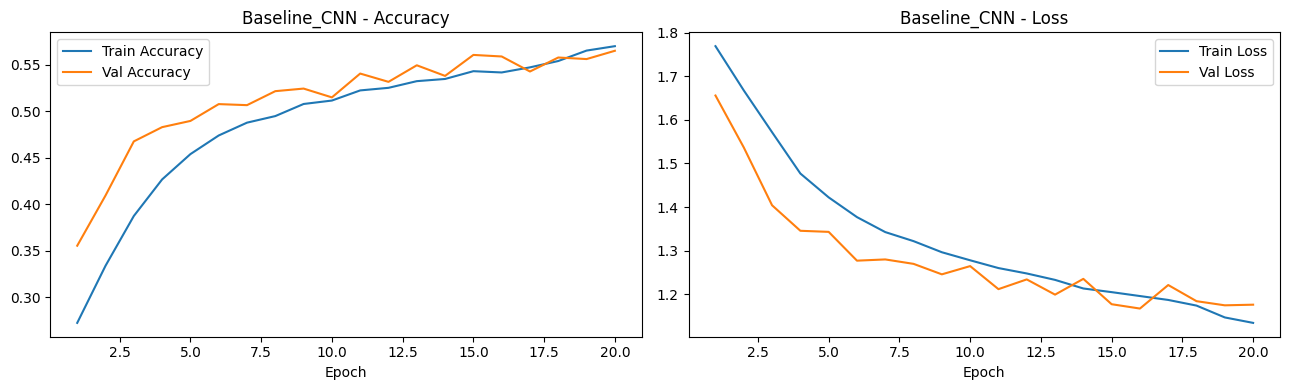

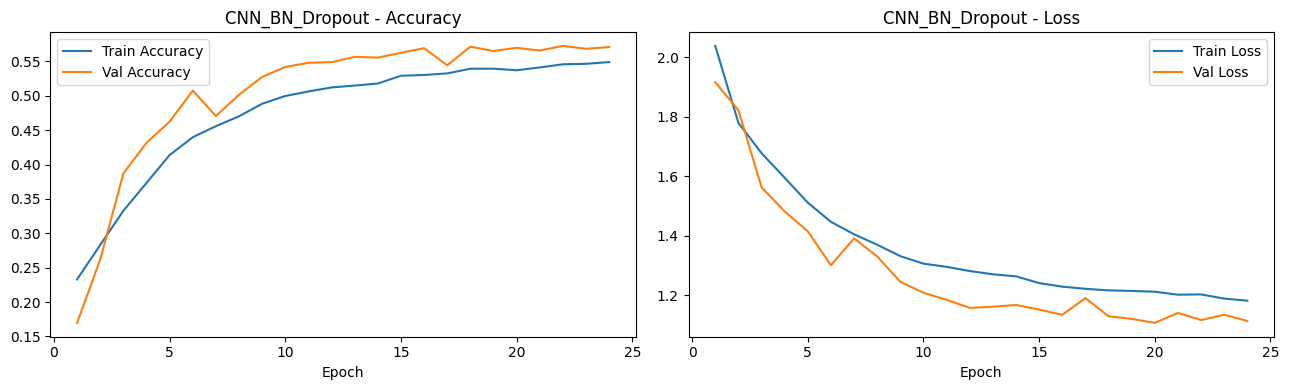

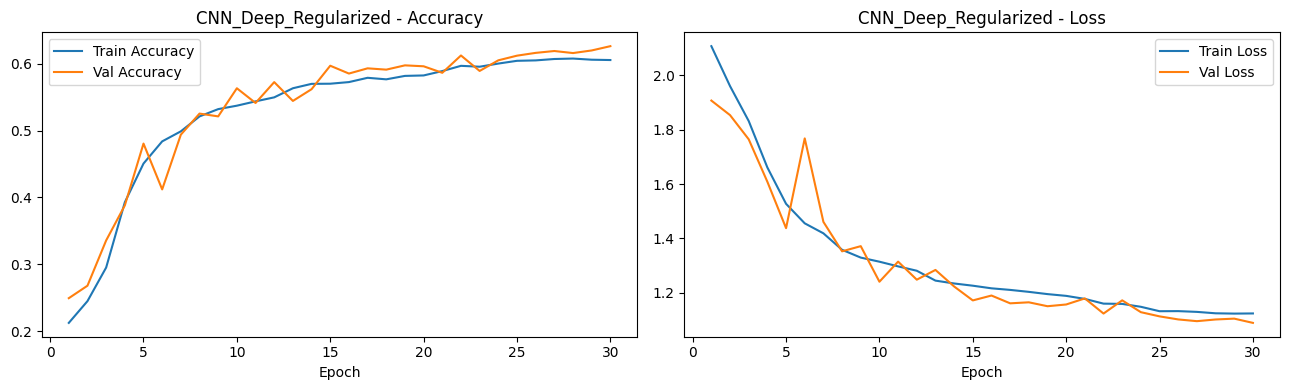

In [ ]:
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


for name, history in histories.items():
    plot_history(history, name)


In [ ]:
results = []

for name, model in trained_models.items():
    history = histories[name]

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    test_loss, test_acc = model.evaluate(test_ds_final, verbose=0)

    overfit_gap = final_train_acc - final_val_acc

    results.append({
        "Model": name,
        "Train Acc": round(final_train_acc, 4),
        "Val Acc": round(final_val_acc, 4),
        "Test Acc": round(test_acc, 4),
        "Overfit Gap (Train-Val)": round(overfit_gap, 4),
        "Epochs Run": len(history.history['accuracy']),
        "Train Time (s)": round(train_times[name], 1)
    })

results_df = pd.DataFrame(results).sort_values(
    "Test Acc", ascending=False
).reset_index(drop=True)

results_df


,Model,Train Acc,Val Acc,Test Acc,Overfit Gap (Train-Val),Epochs Run,Train Time (s)
0,CNN_Deep_Regularized,0.6056,0.6264,0.6372,-0.0207,30,416.1
1,CNN_BN_Dropout,0.5491,0.5709,0.5832,-0.0218,24,336.8
2,Baseline_CNN,0.5700,0.5651,0.5548,0.0050,20,255.6


In [ ]:
# ==========================================
# Experiment 1: Learning Rate
# ==========================================

learning_rates = [1e-3, 5e-4, 1e-4]

lr_results = []
lr_histories = {}

for lr in learning_rates:

    print(f"\n{'='*60}")
    print(f"Training with Learning Rate = {lr}")
    print(f"{'='*60}")

    model = build_cnn_deep_regularized()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds_final,
        validation_data=val_ds_final,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(
        test_ds_final,
        verbose=0
    )

    best_val_acc = max(history.history['val_accuracy'])

    lr_results.append({
        "Learning Rate": lr,
        "Best Val Accuracy": best_val_acc,
        "Test Accuracy": test_acc,
        "Epochs": len(history.history['accuracy'])
    })

    lr_histories[lr] = history


lr_results_df = pd.DataFrame(lr_results)

lr_results_df.sort_values(
    "Test Accuracy",
    ascending=False
)


Training with Learning Rate = 0.001
Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.2179 - loss: 2.0932 - val_accuracy: 0.2494 - val_loss: 1.9961 - learning_rate: 0.0010
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.2622 - loss: 1.9281 - val_accuracy: 0.2371 - val_loss: 1.9436 - learning_rate: 0.0010
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.3485 - loss: 1.7506 - val_accuracy: 0.3703 - val_loss: 1.6810 - learning_rate: 0.0010
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.4260 - loss: 1.5863 - val_accuracy: 0.4288 - val_loss: 1.5338 - learning_rate: 0.0010
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4683 - loss: 1.4903 - val_accuracy: 0.4823 - val_loss: 1.4718 - learning_rate: 0.0010
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.4870 - loss: 1.4344 - val_accuracy: 0.4918 - val_loss: 1.4169 - learning_rate: 0.0010
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━

,Learning Rate,Best Val Accuracy,Test Accuracy,Epochs
0,0.0010,0.611870,0.625801,30
1,0.0005,0.612984,0.618835,30
2,0.0001,0.500697,0.500975,29


In [ ]:
# ==========================================
# Experiment 2: Batch Size
# ==========================================

batch_sizes = [64, 128, 256]

batch_results = {}
batch_histories = {}

for batch_size in batch_sizes:

    print(f"\n{'='*60}")
    print(f"Training with Batch Size = {batch_size}")
    print(f"{'='*60}")

    train_batch = train_ds_final.unbatch().batch(
        batch_size
    ).prefetch(AUTOTUNE)

    val_batch = val_ds_final.unbatch().batch(
        batch_size
    ).prefetch(AUTOTUNE)

    model = build_cnn_deep_regularized()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_batch,
        validation_data=val_batch,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(
        test_ds_final,
        verbose=0
    )

    batch_results[batch_size] = test_acc
    batch_histories[batch_size] = history


batch_results_df = pd.DataFrame(
    list(batch_results.items()),
    columns=["Batch Size", "Test Accuracy"]
)

batch_results_df


Training with Batch Size = 64
Epoch 1/30
    444/Unknown 40s 52ms/step - accuracy: 0.2034 - loss: 2.2187

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


444/444 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.2123 - loss: 2.1201 - val_accuracy: 0.2494 - val_loss: 1.9162 - learning_rate: 5.0000e-04
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.2422 - loss: 1.9661 - val_accuracy: 0.2767 - val_loss: 1.8400 - learning_rate: 5.0000e-04
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.2913 - loss: 1.8504 - val_accuracy: 0.3697 - val_loss: 1.6870 - learning_rate: 5.0000e-04
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.3695 - loss: 1.6965 - val_accuracy: 0.3879 - val_loss: 1.6434 - learning_rate: 5.0000e-04
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.4250 - loss: 1.5779 - val_accuracy: 0.4714 - val_loss: 1.4767 - learning_rate: 5.0000e-04
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.4648 - loss: 1.4929 - val_accuracy: 0.4848 - val_loss: 1.4774 - learning_rate: 5.0000e-04
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accurac

,Batch Size,Test Accuracy
0,64,0.629981
1,128,0.595152
2,256,0.541655


In [ ]:
# ==========================================
# Experiment 3: Dropout
# ==========================================

def build_dropout_model(
    dropout_rate=0.3,
    input_shape=IMG_SHAPE,
    num_classes=NUM_CLASSES
):

    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(
        32, (3,3), padding="same"
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        32, (3,3), padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Block 2
    x = layers.Conv2D(
        64, (3,3), padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        64, (3,3), padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Block 3
    x = layers.Conv2D(
        128, (3,3), padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        128, (3,3), padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)

    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    return models.Model(
        inputs,
        outputs,
        name=f"CNN_Dropout_{dropout_rate}"
    )

In [ ]:
dropout_rates = [0.2, 0.3, 0.5]

dropout_results = []
dropout_histories = {}

for dropout in dropout_rates:

    print(f"\n{'='*60}")
    print(f"Training with Dropout = {dropout}")
    print(f"{'='*60}")

    model = build_dropout_model(dropout)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds_final,
        validation_data=val_ds_final,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(
        test_ds_final,
        verbose=0
    )

    dropout_results.append({
        "Dropout": dropout,
        "Best Val Accuracy": max(
            history.history["val_accuracy"]
        ),
        "Test Accuracy": test_acc
    })

    dropout_histories[dropout] = history


dropout_results_df = pd.DataFrame(
    dropout_results
)

dropout_results_df.sort_values(
    "Test Accuracy",
    ascending=False
)


Training with Dropout = 0.2
Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 86s 81ms/step - accuracy: 0.2540 - loss: 1.7940 - val_accuracy: 0.1691 - val_loss: 2.0884 - learning_rate: 5.0000e-04
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.3231 - loss: 1.6845 - val_accuracy: 0.2572 - val_loss: 2.0850 - learning_rate: 5.0000e-04
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.3844 - loss: 1.5718 - val_accuracy: 0.3399 - val_loss: 1.7334 - learning_rate: 5.0000e-04
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.4266 - loss: 1.4854 - val_accuracy: 0.4171 - val_loss: 1.4908 - learning_rate: 5.0000e-04
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.4483 - loss: 1.4317 - val_accuracy: 0.4425 - val_loss: 1.4405 - learning_rate: 5.0000e-04
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.4713 - loss: 1.3826 - val_accuracy: 0.4751 - val_loss: 1.3820 - learning_rate: 5.0000e-04
Epoch 7/30
222/222 ━━━━

,Dropout,Best Val Accuracy,Test Accuracy
0,0.2,0.572304,0.580106
1,0.3,0.547506,0.553915
2,0.5,0.427138,0.422123


In [ ]:
# ==========================================
# FINAL MODEL
# ==========================================

FINAL_LR = 0.001
FINAL_BATCH_SIZE = 64
FINAL_DROPOUT = 0.2

final_model = build_dropout_model(
    dropout_rate=FINAL_DROPOUT
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINAL_LR
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

final_history = final_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=50,
    callbacks=final_callbacks,
    verbose=1
)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.2553 - loss: 1.7916 - val_accuracy: 0.1691 - val_loss: 1.8910 - learning_rate: 0.0010
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.3332 - loss: 1.6604 - val_accuracy: 0.2828 - val_loss: 1.9586 - learning_rate: 0.0010
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.4158 - loss: 1.5036 - val_accuracy: 0.4235 - val_loss: 1.4540 - learning_rate: 0.0010
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.4538 - loss: 1.4153 - val_accuracy: 0.4322 - val_loss: 1.5072 - learning_rate: 0.0010
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4777 - loss: 1.3618 - val_accuracy: 0.4884 - val_loss: 1.3498 - learning_rate: 0.0010
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.4920 - loss: 1.3246 - val_accuracy: 0.4823 - val_loss: 1.3663 - learning_rate: 0.0010
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5057 - l

In [ ]:
def analyze_overfitting(history):

    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    best_val_epoch = np.argmax(val_acc)

    train_best = train_acc[best_val_epoch]
    val_best = val_acc[best_val_epoch]

    gap = train_best - val_best

    print("Best Epoch:", best_val_epoch + 1)
    print("Training Accuracy:", round(train_best, 4))
    print("Validation Accuracy:", round(val_best, 4))
    print("Accuracy Gap:", round(gap, 4))

    if gap > 0.10:
        print("Diagnosis: Overfitting")

    elif train_best < 0.70 and val_best < 0.70:
        print("Diagnosis: Underfitting")

    else:
        print("Diagnosis: Good Fit")

In [ ]:
def plot_final_history(history):

    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        acc,
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        val_acc,
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        "Training vs Validation Accuracy"
    )

    plt.legend()
    plt.show()


    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        loss,
        label="Training Loss"
    )

    plt.plot(
        epochs,
        val_loss,
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        "Training vs Validation Loss"
    )

    plt.legend()
    plt.show()

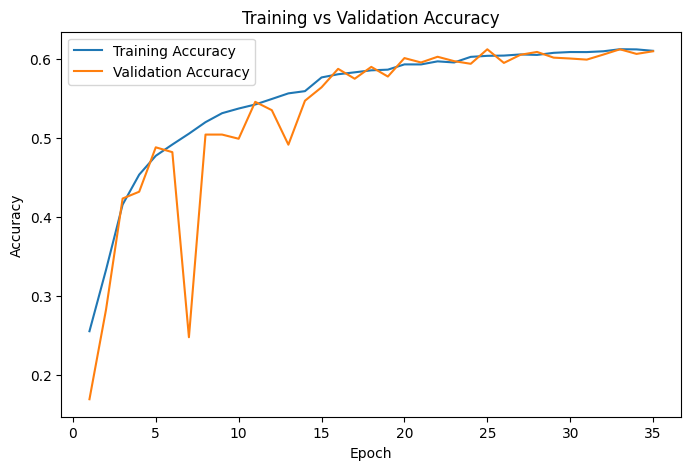

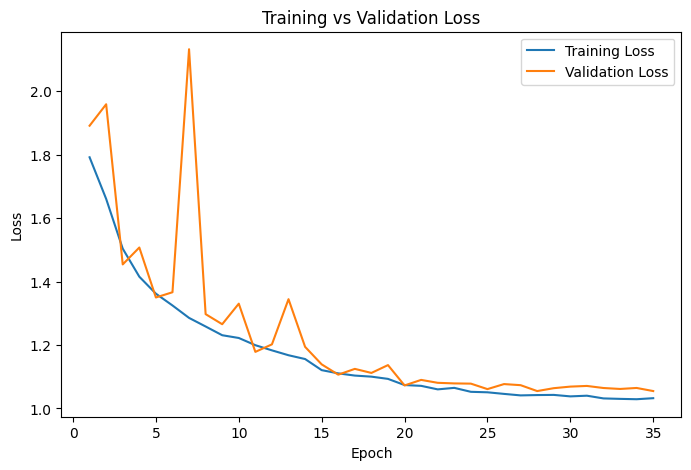

In [ ]:
plot_final_history(final_history)

In [ ]:
analyze_overfitting(final_history)

Best Epoch: 25
Training Accuracy: 0.6044
Validation Accuracy: 0.6127
Accuracy Gap: -0.0083
Diagnosis: Underfitting


In [ ]:
# ==========================================
# FINAL MODEL - REDUCING UNDERFITTING
# ==========================================

FINAL_LR = 0.001
FINAL_BATCH_SIZE = 64
FINAL_DROPOUT = 0.1

final_model = build_dropout_model(
    dropout_rate=FINAL_DROPOUT
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINAL_LR
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]

final_history = final_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=60,
    callbacks=final_callbacks,
    verbose=1
)

Epoch 1/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.2646 - loss: 1.7786 - val_accuracy: 0.1691 - val_loss: 2.1545 - learning_rate: 0.0010
Epoch 2/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.3635 - loss: 1.5981 - val_accuracy: 0.2026 - val_loss: 2.1470 - learning_rate: 0.0010
Epoch 3/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.4435 - loss: 1.4522 - val_accuracy: 0.4586 - val_loss: 1.3988 - learning_rate: 0.0010
Epoch 4/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.4789 - loss: 1.3662 - val_accuracy: 0.4394 - val_loss: 1.4523 - learning_rate: 0.0010
Epoch 5/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5021 - loss: 1.3041 - val_accuracy: 0.3842 - val_loss: 1.6292 - learning_rate: 0.0010
Epoch 6/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.5205 - loss: 1.2593 - val_accuracy: 0.5216 - val_loss: 1.2462 - learning_rate: 0.0010
Epoch 7/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.5339 - l

In [ ]:
final_test_loss, final_test_accuracy = final_model.evaluate(
    test_ds_final,
    verbose=1
)

print(f"Final Test Accuracy: {final_test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {final_test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6294 - loss: 0.9782
Final Test Accuracy: 62.94%
Final Test Loss: 0.9782


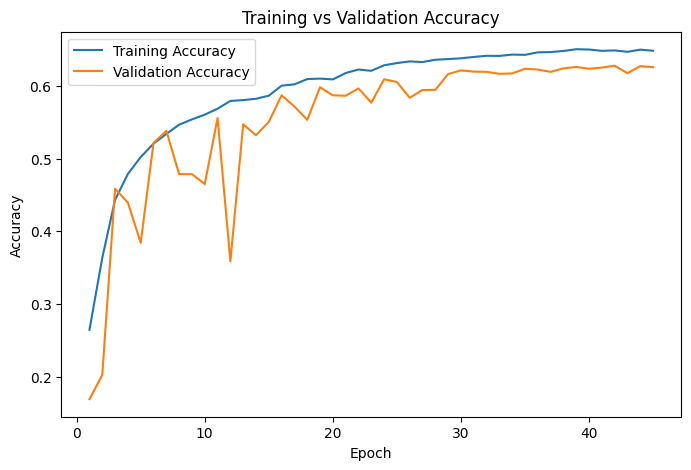

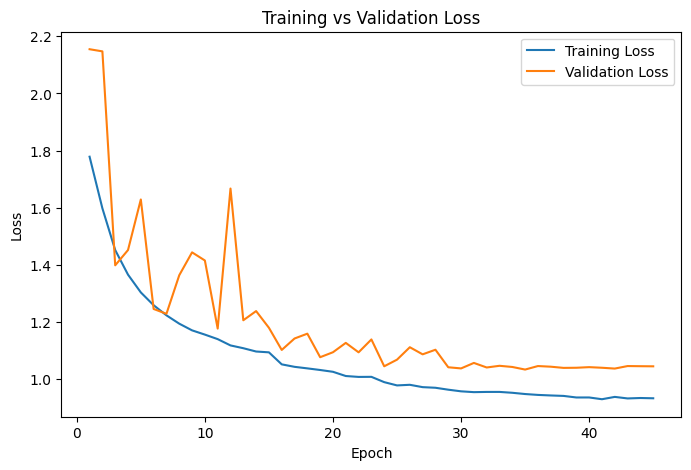

In [ ]:
plot_final_history(final_history)

In [ ]:
analyze_overfitting(final_history)

Best Epoch: 42
Training Accuracy: 0.6488
Validation Accuracy: 0.6278
Accuracy Gap: 0.021
Diagnosis: Underfitting


## Model Evaluation with TensorFlow/Keras and scikit-learn

Since our `final_model` is a TensorFlow/Keras model, we need to evaluate it using compatible methods. We'll get predictions from the Keras model and then use `scikit-learn` for metrics and confusion matrices, which works well with NumPy arrays generated by Keras.

In [ ]:
# Get true labels and predictions from the Keras model
y_true_labels = []
y_pred_probabilities = []

for images, labels in test_ds_final:
    y_true_labels.extend(labels.numpy())
    y_pred_probabilities.extend(final_model.predict(images, verbose=0))

y_true = np.array(y_true_labels)
y_pred = np.argmax(np.array(y_pred_probabilities), axis=1)

print("Shape of true labels:", y_true.shape)
print("Shape of predicted labels:", y_pred.shape)

Shape of true labels: (3589,)
Shape of predicted labels: (3589,)


Accuracy : 0.6294
Precision: 0.6325
Recall   : 0.6294
F1-score : 0.6236

Classification Report:

              precision    recall  f1-score   support

       Anger       0.58      0.55      0.57       491
     Disgust       0.50      0.13      0.20        55
        Fear       0.51      0.33      0.40       528
   Happiness       0.83      0.88      0.86       879
     Neutral       0.61      0.60      0.61       626
     Sadness       0.44      0.61      0.51       594
    Surprise       0.75      0.70      0.72       416

    accuracy                           0.63      3589
   macro avg       0.60      0.54      0.55      3589
weighted avg       0.63      0.63      0.62      3589



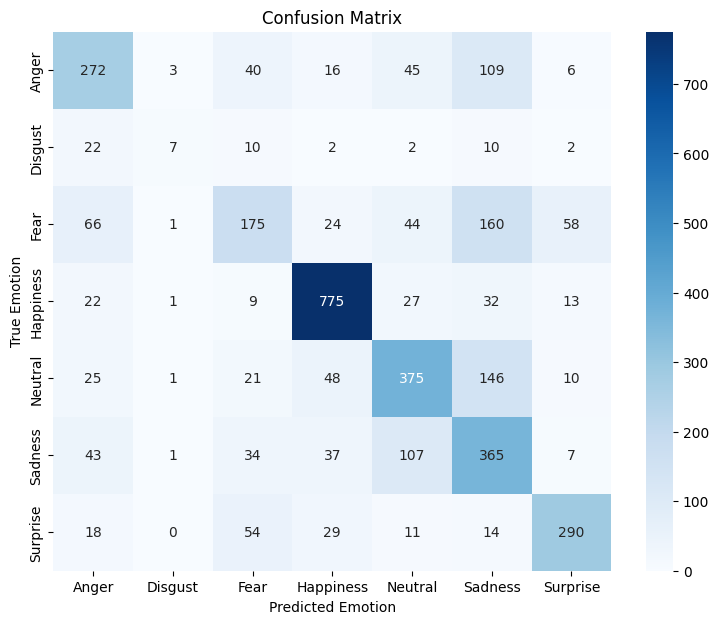

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, zero_division=0))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=EMOTION_LABELS,
    yticklabels=EMOTION_LABELS
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

def analyze_confusion_matrix(cm_matrix, labels):
    cm_copy = cm_matrix.copy()
    np.fill_diagonal(cm_copy, 0) # Remove diagonal as correct predictions are not confusion

    max_index = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)

    true_class = labels[max_index[0]]
    predicted_class = labels[max_index[1]]
    max_value = cm_copy[max_index]

    print(
        f"Most common confusion: "
        f"{true_class} \u2192 {predicted_class}"
    )
    print(
        f"Number of misclassified samples: {max_value}"
    )

analyze_confusion_matrix(cm, EMOTION_LABELS)

Most common confusion: Fear → Sadness
Number of misclassified samples: 160


## Visualize Misclassified Images (Keras Compatible)

Let's adapt the misclassification visualization to work directly with the Keras model's predictions.

Found 1330 misclassified images.


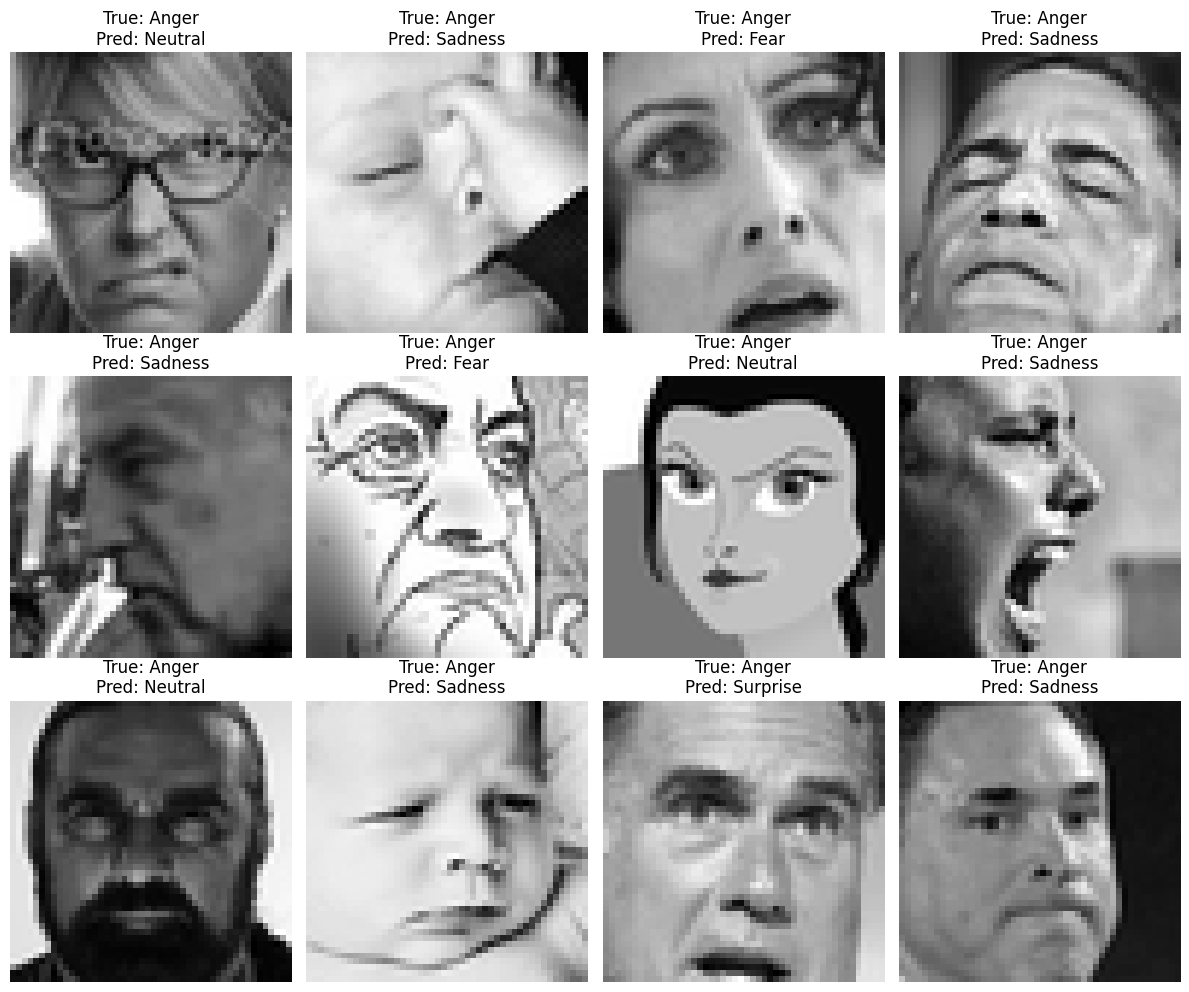

In [ ]:
def get_keras_misclassified_images(model, dataset, num_classes):
    wrong_images = []
    wrong_true = []
    wrong_pred = []

    # Get all images and labels from the test dataset
    all_images = []
    all_labels = []
    for images_batch, labels_batch in dataset:
        all_images.append(images_batch.numpy())
        all_labels.append(labels_batch.numpy())

    all_images = np.concatenate(all_images, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Get predictions for all images
    all_predictions_prob = model.predict(dataset, verbose=0)
    all_predictions = np.argmax(all_predictions_prob, axis=1)

    for i in range(len(all_labels)):
        if all_predictions[i] != all_labels[i]:
            wrong_images.append(all_images[i])
            wrong_true.append(all_labels[i])
            wrong_pred.append(all_predictions[i])

    return wrong_images, wrong_true, wrong_pred


def show_misclassified(wrong_images, wrong_true, wrong_pred, num_images=12):
    plt.figure(figsize=(12, 10))

    for i in range(min(num_images, len(wrong_images))):
        image = wrong_images[i]

        # Remove the channel dimension for grayscale image plotting if it's 1
        if image.shape[-1] == 1:
            image = image.squeeze(axis=-1)

        plt.subplot(3, 4, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"True: {EMOTION_LABELS[wrong_true[i]]}\n"
            f"Pred: {EMOTION_LABELS[wrong_pred[i]]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


wrong_images, wrong_true, wrong_pred = get_keras_misclassified_images(final_model, test_ds_final, NUM_CLASSES)

print(f"Found {len(wrong_images)} misclassified images.")
show_misclassified(wrong_images, wrong_true, wrong_pred)

## Single Image Inference with Keras Model

Here's how to perform inference on a single image using your `final_model`.

In [ ]:
from PIL import Image
import numpy as np

# Example: Create a dummy image or load one
# For demonstration, let's create a black image (replace with your actual 'test_face.jpg' loading logic)
try:
    image = Image.open("test_face.jpg").convert("L") # Convert to grayscale for your model
except FileNotFoundError:
    print("test_face.jpg not found. Creating a dummy black image for demonstration.")
    image = Image.fromarray(np.zeros((48, 48), dtype=np.uint8))

# Preprocessing steps matching your training data
image = image.resize(IMG_SIZE) # Ensure it's 48x48
image_array = np.array(image).astype(np.float32) / 255.0 # Normalize
image_tensor = np.expand_dims(image_array, axis=0) # Add batch dimension
image_tensor = np.expand_dims(image_tensor, axis=-1) # Add channel dimension (48, 48, 1)


# Get predictions from the final_model (Keras)
predictions = final_model.predict(image_tensor, verbose=0)
probabilities = tf.nn.softmax(predictions, axis=1).numpy()[0]

predicted_class_idx = np.argmax(probabilities)
confidence = probabilities[predicted_class_idx]

print(
    "Emotion:",
    EMOTION_LABELS[predicted_class_idx]
)

print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

test_face.jpg not found. Creating a dummy black image for demonstration.
Emotion: Sadness
Confidence: 26.92%


In [ ]:
analyze_confusion_matrix(
    cm,
    EMOTION_LABELS
)

Most common confusion: Fear → Sadness
Number of misclassified samples: 160


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame(results).T

comparison_df

,0,1,2
Model,Baseline_CNN,CNN_BN_Dropout,CNN_Deep_Regularized
Train Acc,0.57,0.5491,0.6056
Val Acc,0.5651,0.5709,0.6264
Test Acc,0.5548,0.5832,0.6372
Overfit Gap (Train-Val),0.005,-0.0218,-0.0207
Epochs Run,20,24,30
Train Time (s),255.6,336.8,416.1
